In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [87]:
df = pd.read_csv("data_raw.csv", parse_dates=["timestamp"])
df.sort_values("timestamp", inplace=True)
df.tail()

,timestamp,temperature_raw,growth_raw,humidity_raw,co2_raw
335,2026-02-19 21:08:42,0.979,0.483,0.843,0.146
336,2026-02-19 21:09:43,0.980,0.483,0.849,0.149
337,2026-02-19 21:10:43,0.981,0.483,0.866,0.151
338,2026-02-19 21:11:44,0.983,0.483,0.859,0.154
339,2026-02-19 21:12:44,0.984,0.483,0.860,0.154


<Axes: >

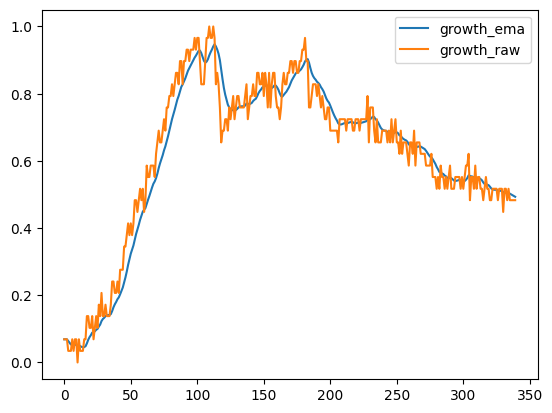

In [154]:
# Exponential moving average

df["growth_ema"] = df["growth_raw"].ewm(alpha=0.4).mean()
df["growth_ema"] = df["growth_ema"].ewm(alpha=0.2).mean()
df[["growth_ema", "growth_raw"]].plot()

<Axes: >

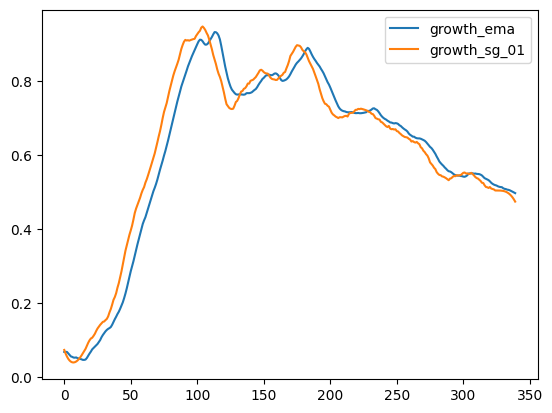

In [89]:
# SG Offline

from scipy.signal import savgol_filter

window_01 = 31 # must be odd
polyorder_01 = 3

df["growth_sg_01"] = savgol_filter(
    df["growth_raw"], window_length=window_01, polyorder=polyorder_01
)
df[["growth_ema", "growth_sg_01"]].plot()

<Axes: >

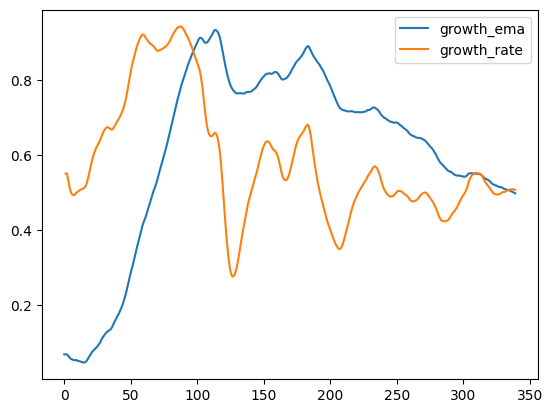

In [90]:
# Growth Rate
dt = 60 # minutes
df["growth_rate"] = df["growth_ema"].diff() / dt
df["growth_rate"] = (df["growth_rate"] - df["growth_rate"].min()) / (df["growth_rate"].max() - df["growth_rate"].min())
df["growth_rate"] = df["growth_rate"].ewm(alpha=0.2).mean()
df["growth_rate"] = df["growth_rate"].ewm(alpha=0.2).mean()

df[["growth_ema", "growth_rate"]].plot()

<Axes: >

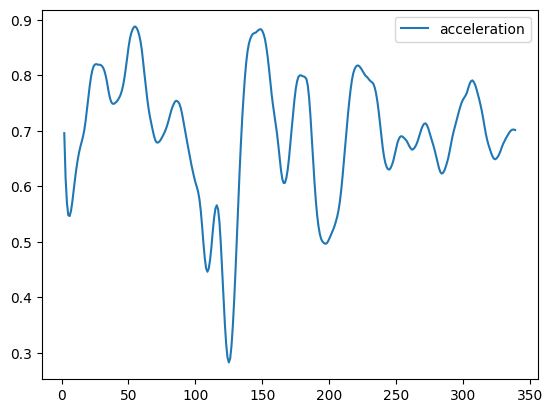

In [133]:
# Growth Rate
dt = 60  # minutes
df["acceleration"] = df["growth_rate"].diff(1) / dt
df["acceleration"] = (df["acceleration"] - df["acceleration"].min()) / (
    df["acceleration"].max() - df["acceleration"].min()
)
df["acceleration"] = df["acceleration"].ewm(alpha=0.2).mean()
df["acceleration"] = df["acceleration"].ewm(alpha=0.25).mean()

df[["acceleration"]].plot()

<Axes: >

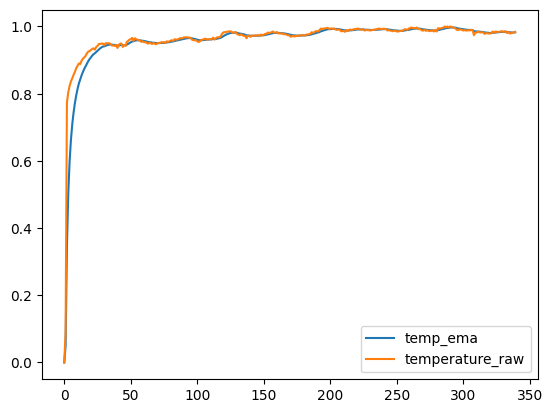

In [97]:
# Temperature

df["temp_ema"] = df["temperature_raw"].ewm(alpha=0.2).mean()
df[["temp_ema", "temperature_raw"]].plot()

<Axes: >

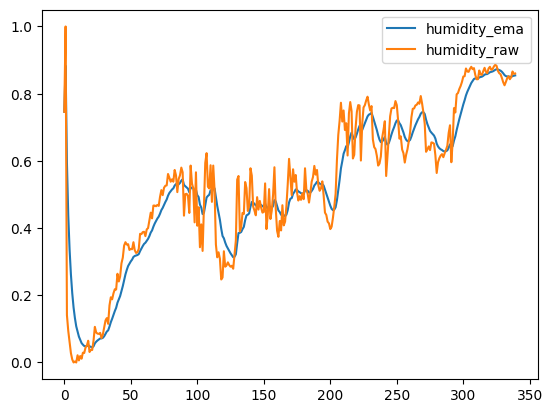

In [109]:
# Humidity

df["humidity_ema"] = df["humidity_raw"].ewm(alpha=0.15).mean()
df[["humidity_ema", "humidity_raw"]].plot()

<Axes: >

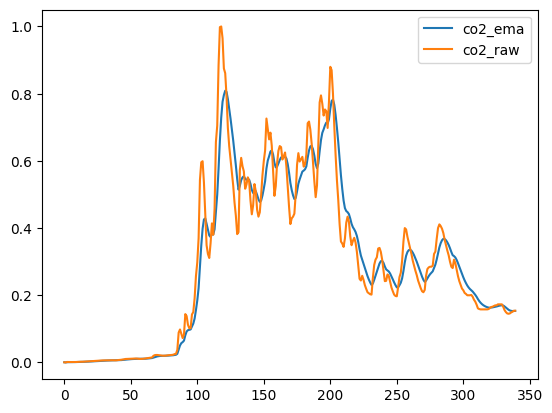

In [113]:
# CO2

df["co2_ema"] = df["co2_raw"].ewm(alpha=0.2).mean()
df[["co2_ema", "co2_raw"]].plot()

<Axes: >

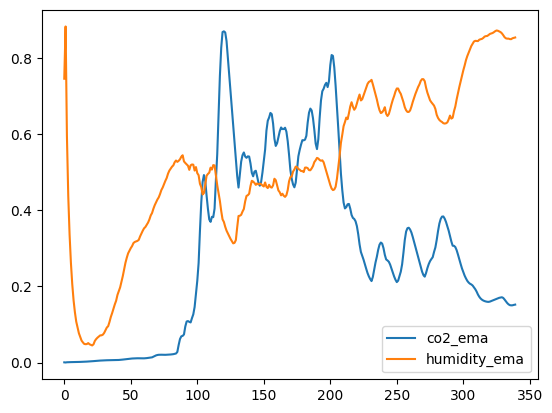

In [112]:
df[["co2_ema", "humidity_ema"]].plot()